In [ ]:
!pip install kagglehub[pandas-datasets]

In [ ]:
import os
import pandas as pd

base = "/kaggle/input/imdb-dataset"
files = os.listdir(base)
print(files)

# pick the csv automatically (adjust if multiple)
csv_files = [f for f in files if f.lower().endswith(".csv")]
print("CSV files:", csv_files)

df = pd.read_csv(os.path.join(base, csv_files[0]))
df.head()

['imdb_top_1000.csv']
CSV files: ['imdb_top_1000.csv']


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [51]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   int64  
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(2), object(12)
memory usage: 125.1+ KB


,Runtime,IMDB_Rating,Meta_score,No_of_Votes
count,1000.000000,1000.000000,843.000000,1.000000e+03
mean,122.891000,7.949300,77.971530,2.736929e+05
std,28.093671,0.275491,12.376099,3.273727e+05
min,45.000000,7.600000,28.000000,2.508800e+04
25%,103.000000,7.700000,70.000000,5.552625e+04
50%,119.000000,7.900000,79.000000,1.385485e+05
75%,137.000000,8.100000,87.000000,3.741612e+05
max,321.000000,9.300000,100.000000,2.343110e+06


## Data Cleaning

In [ ]:
# Convert the runtime to numeric minutes
display(df["Runtime"].head())
# df['Runtime'] = df['Runtime'].str.replace(' min','').astype(int)

# Clean Gross revenue column
display(df["Gross"].head())
# df["Gross"] = df["Gross"].str.replace(",","")
# df["Gross"] = pd.to_numeric(df["Gross"], errors='coerce')

# Fill missing meta score with the mean
df["Meta_score"].isnull().sum()
df["Meta_score"] = df["Meta_score"].fillna(df["Meta_score"].mean())
df["Meta_score"].isnull().sum()

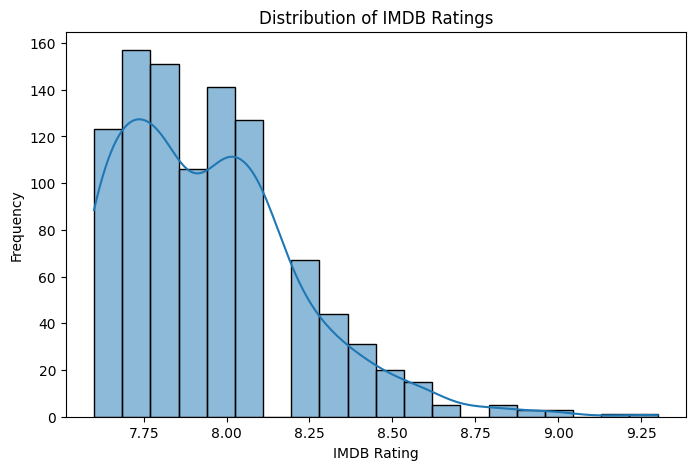

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["IMDB_Rating"], bins=20, kde=True)
plt.title("Distribution of IMDB Ratings")
plt.xlabel("IMDB Rating")
plt.ylabel("Frequency")
plt.show()

## Most Comman Genre

In [88]:
#Most Common Genres

from collections import Counter

genres = df['Genre'].str.split(', ')
all_genres = [g for sublist in genres for g in sublist]

genre_counts = Counter(all_genres)
genre_df = pd.DataFrame(genre_counts.items(), columns=['Genre','Count']).sort_values(by='Count', ascending=False)

display(genre_df.head(10))

,Genre,Count
0,Drama,724
10,Comedy,233
1,Crime,209
3,Adventure,196
2,Action,189
11,Thriller,137
7,Romance,125
4,Biography,109
15,Mystery,99
12,Animation,82


Text(0.5, 1.0, 'Top 10 Movies Genres')

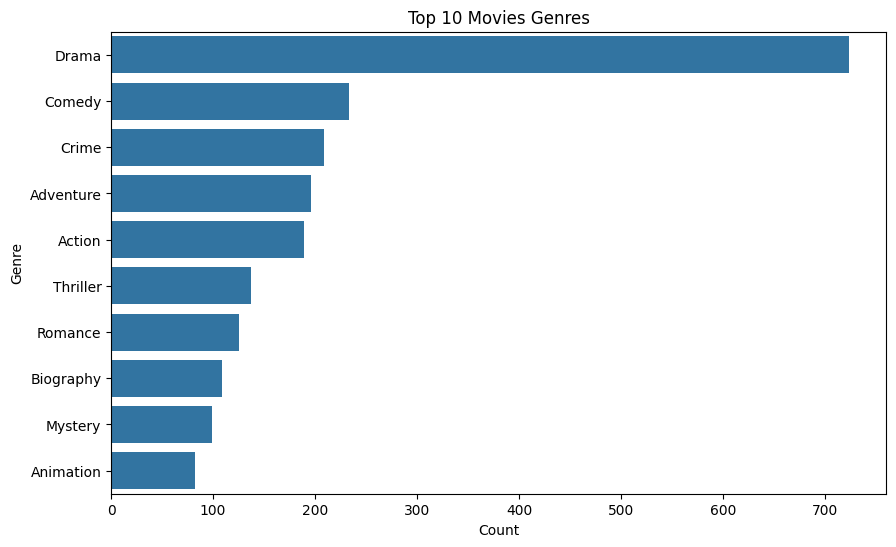

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x='Count', y='Genre', data=genre_df.head(10))
plt.title("Top 10 Movies Genres")

In [ ]:
# Ratings by Genre
rating_avg_by_genre = []

for genre in genre_df['Genre']:
    avg_rating = df[df['Genre'].str.contains(genre)]['IMDB_Rating'].mean()
    # print(f"{genre}: {avg_rating:.2f}")
    rating_avg_by_genre.append(avg_rating)

genre_df['avg_rating'] = rating_avg_by_genre
genre_df = genre_df.sort_values(by='avg_rating', ascending=False)
display(genre_df.head(10))


,Genre,Count,avg_rating
14,War,51,8.013725
8,Western,20,8.000000
19,Film-Noir,19,7.989474
6,Sci-Fi,67,7.977612
15,Mystery,99,7.967677
0,Drama,724,7.959392
1,Crime,209,7.954545
5,History,56,7.953571
3,Adventure,196,7.952041
2,Action,189,7.948677


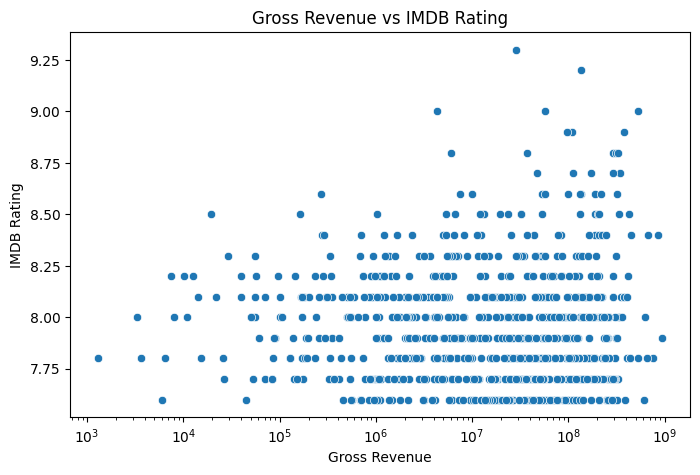

In [ ]:
# Gross vs Rating
plt.figure(figsize=(8,5))
sns.scatterplot(x='Gross', y='IMDB_Rating', data=df)
plt.xscale('log') 
plt.title("Gross Revenue vs IMDB Rating")
plt.xlabel("Gross Revenue")
plt.ylabel("IMDB Rating")
plt.show()

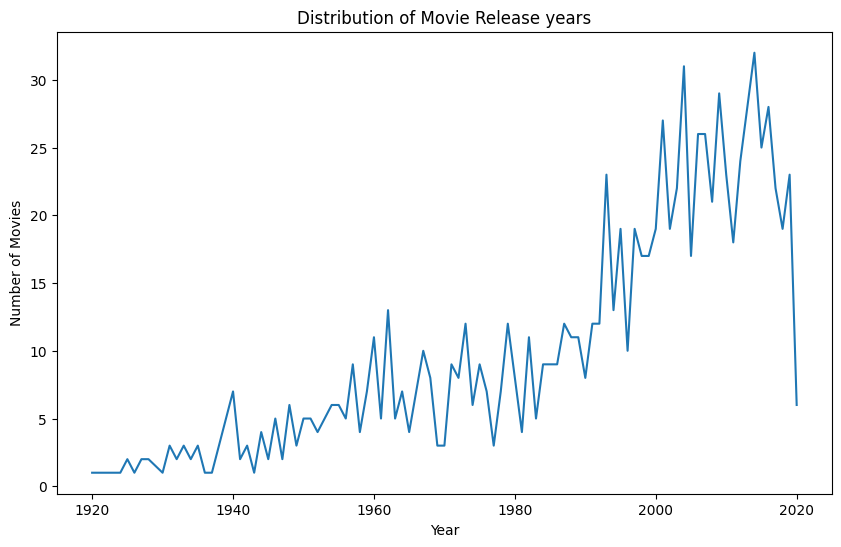

In [100]:
# Movie release year distribution
df['Released_Year'] = pd.to_numeric(df['Released_Year'], errors='coerce')

plt.figure(figsize=(10,6))
df['Released_Year'].value_counts().sort_index().plot()
plt.title("Distribution of Movie Release years")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.show()

In [ ]:
# Top directors by average rating
director_avg_rating = df.groupby('Director')['IMDB_Rating'].mean().sort_values(ascending=False)
display(director_avg_rating.head(10))


,IMDB_Rating
Director,
Frank Darabont,8.95
Irvin Kershner,8.70
Lana Wachowski,8.70
Sudha Kongara,8.60
Roberto Benigni,8.60
Thomas Kail,8.60
George Lucas,8.60
Fernando Meirelles,8.60
Masaki Kobayashi,8.60


In [ ]:

# Predict the rating
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Define target
target_col = "IMDB_Rating"

# define feauture
X = df.drop(columns=[target_col])
y = df[target_col]

#) Clean Director
df["Director"] = df["director"].astype(str).str.strip()
df["Director"] = df["Director"].replace({"":"Unknown", "nan":"Unknown"})

# one-hot encode the director
cat_cols = ["Director"]
num_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer([
    
])

